## Introduction

This project focuses on predicting whether an individual earns more than 50K per year using a classification approach. The analysis includes data exploration, preprocessing, and the application of multiple machine learning models to evaluate performance and identify key factors influencing income levels.

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

##Data Loading

In [44]:
df = pd.read_csv('/content/adultcensusincome.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


##Data Cleaning

In [45]:
print (df.shape)
df.info()
print(df.isnull().sum())

(32561, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occup

In [46]:
df = df.replace('?', np.nan)

df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation']= df['occupation'].fillna('Unknown')
df['native.country'] = df['native.country'].fillna('Unknown')

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
sex,0
capital.gain,0


In [47]:
if 'fnlwgt' in df.columns:
    df.drop('fnlwgt', axis=1, inplace=True)
else:
    print("'fnlwgt' column not found, skipping drop operation.")

##Exploratory Data Analysis

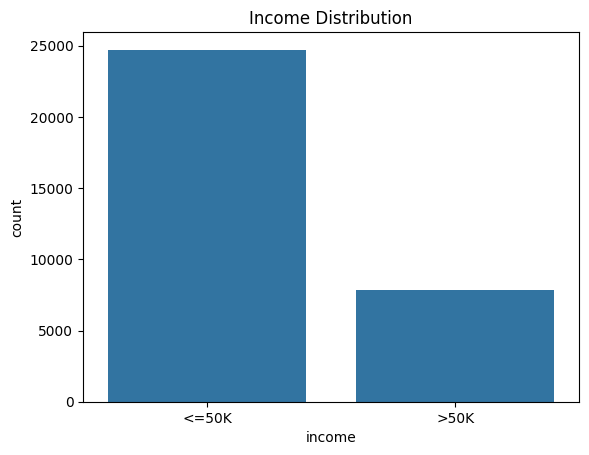

In [48]:
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

##Observation
The dataset is imbalanced, with a higher number of individuals earning <=50K compared to >50K. This imbalance may affect model performance, especially for the minority class, and requires appropriate evaluation metrics and potential resampling techniques.

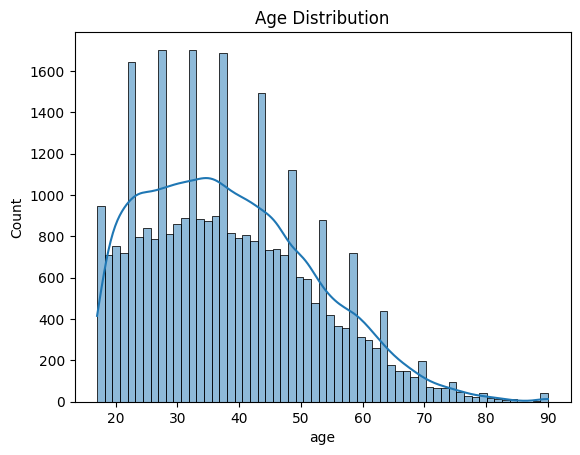

In [49]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

##Observations
The age distribution is slightly right-skewed, with most individuals concentrated between 25 and 45 years old. The frequency decreases as age increases, indicating fewer older individuals in the dataset.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

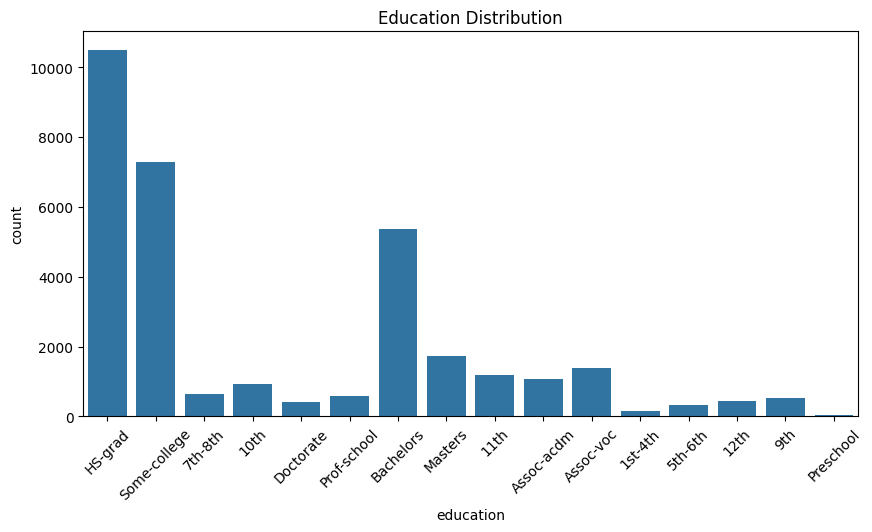

In [50]:
plt.figure(figsize=(10, 5))
sns.countplot(x='education', data=df)
plt.xticks(rotation=45)
plt.title("Education Distribution")
plt

##Observations

The dataset is heavily concentrated around individuals with high school and some college education, with a notable number holding bachelor's degrees. Advanced education levels such as doctorate are significantly underrepresented. This suggests the population is skewed toward mid-level educational attainment, which may influence income or classification outcomes in later analysis.

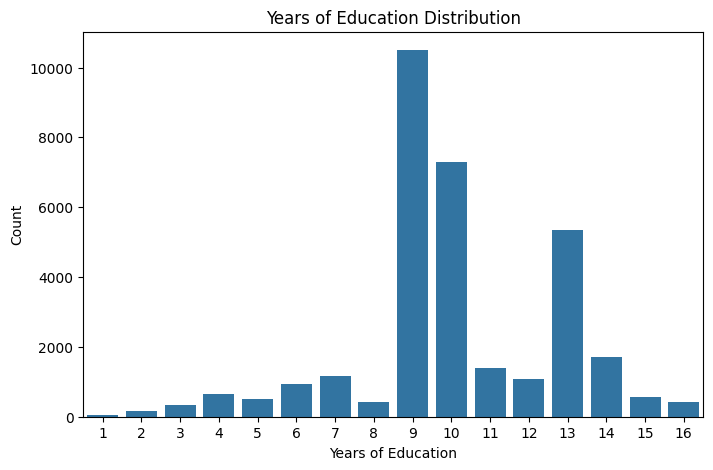

In [51]:
plt.figure(figsize=(8, 5))
sns.countplot(x='education.num', data=df)
plt.title("Years of Education Distribution")
plt.xlabel("Years of Education")
plt.ylabel("Count")
plt.show()

##Observations

The distribution of years of education is heavily concentrated around 9 to 10 years, indicating that most individuals have completed high school or have some level of college education. Higher education levels beyond this range are less frequent, suggesting the dataset is skewed toward mid-level educational attainment.

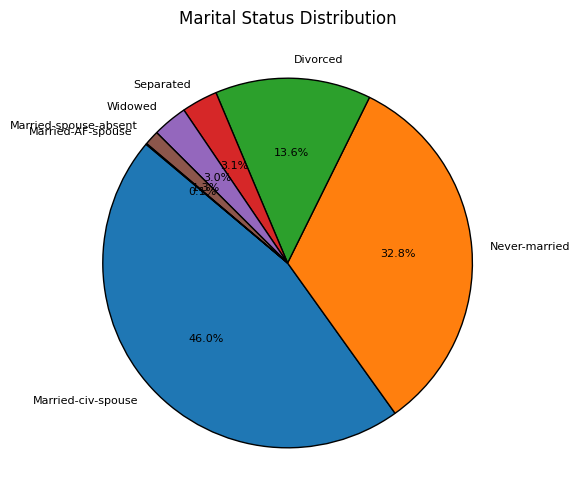

In [52]:
marital_counts = df['marital.status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8},
    wedgeprops={'edgecolor': 'black'}
    )
plt.title('Marital Status Distribution')
plt.show()

##Observations

The dataset is dominated by married individuals (Married-civ-spouse), followed by never-married individuals. Other categories such as divorced, separated, and widowed represent a much smaller portion. This indicates that the population is primarily composed of married or single individuals, which may influence income patterns in later analysis.

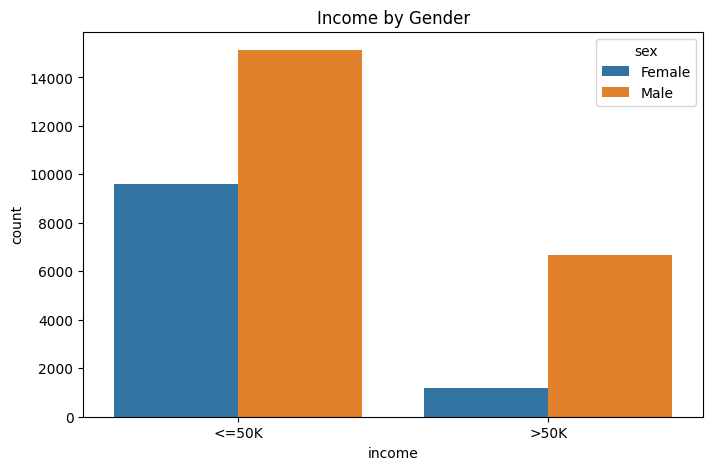

In [53]:
plt.figure(figsize=(8, 5))
sns.countplot(x='income', hue='sex', data=df)
plt.title("Income by Gender")
plt.show()

##Observations

The distribution shows that males have a higher representation in both income categories compared to females. This difference is more pronounced in the >50K category, where males significantly outnumber females. This suggests a potential relationship between gender and income levels, which may influence model predictions in later stages.

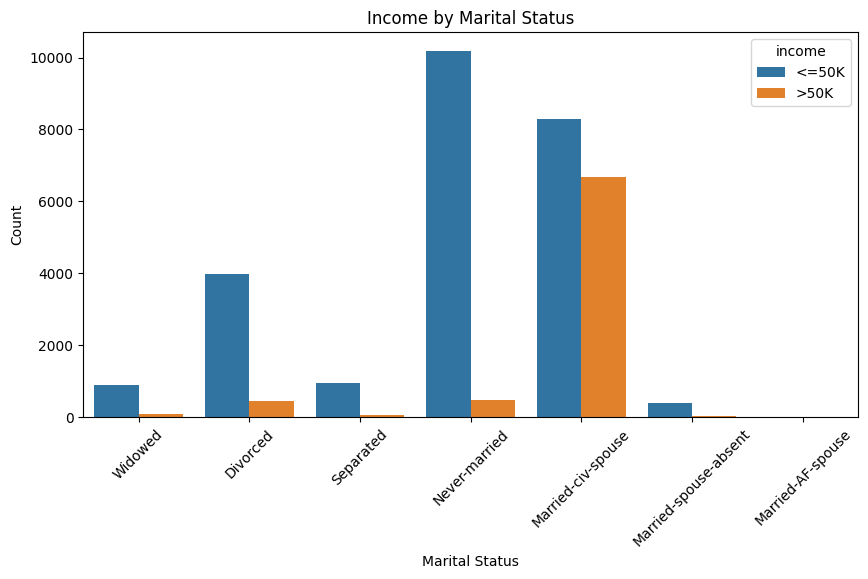

In [54]:
plt.figure(figsize=(10, 5))
sns.countplot(x='marital.status', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Income by Marital Status")
plt.ylabel("Count")
plt.xlabel("Marital Status")
plt.show()

##Observations

The distribution shows that individuals who are married (Married-civ-spouse) have a higher representation in the >50K income category compared to other marital groups. In contrast, individuals who are never married are predominantly in the <=50K category. This suggests that marital status may have a strong relationship with income levels, particularly for married individuals.

##Correlation Analysis

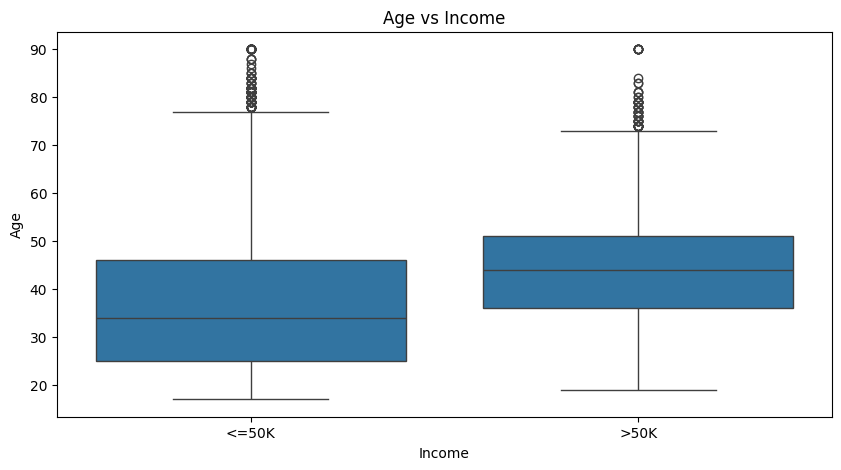

In [55]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

##Observations

The boxplot shows that individuals earning more than 50K tend to be older, with a higher median age compared to those earning less than or equal to 50K. The distribution for higher income is more concentrated in the middle-age range, while the lower income group includes a wider range of younger individuals. This suggests that age and experience may play an important role in income levels.

In [56]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

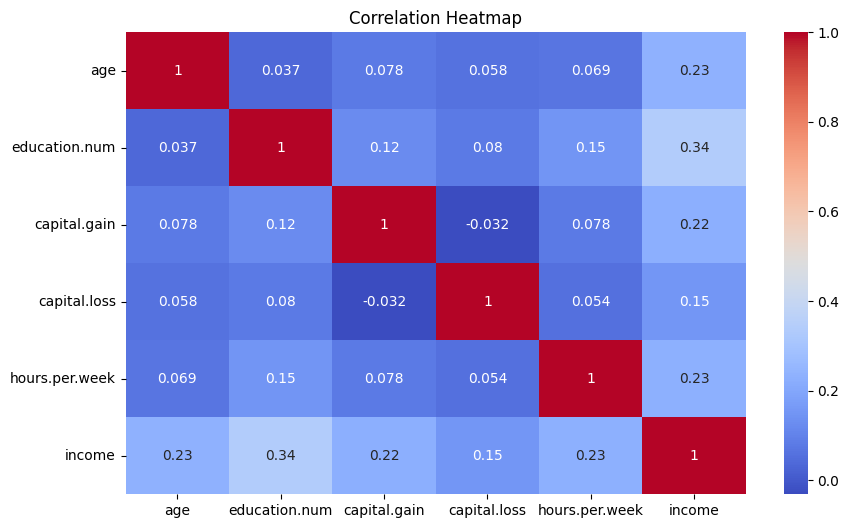

In [57]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##Observations

The correlation heatmap shows generally weak to moderate relationships among numerical variables. Among them, education.num has the strongest positive correlation with income, followed by age, hours per week, and capital gain. This indicates that income is influenced by multiple factors rather than a single dominant variable, with education level being the most relevant numerical predictor.

##Data Preparation

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [59]:
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,7,11,9,6,14,1,0,0,4356,40,38,0
1,82,3,11,9,6,3,1,0,0,4356,18,38,0
2,66,7,15,10,6,14,4,0,0,4356,40,38,0
3,54,3,5,4,0,6,4,0,0,3900,40,38,0
4,41,3,15,10,5,9,3,0,0,3900,40,38,0


In [60]:
X = df.drop('income', axis=1)
y = df['income']

##Model Training

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Model Comparison

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [64]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8096115461384923
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4976
           1       0.67      0.38      0.48      1537

    accuracy                           0.81      6513
   macro avg       0.75      0.66      0.68      6513
weighted avg       0.79      0.81      0.79      6513



In [66]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [67]:
y_pred = model.predict(X_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.822201750345463
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4976
           1       0.70      0.44      0.54      1537

    accuracy                           0.82      6513
   macro avg       0.77      0.69      0.71      6513
weighted avg       0.81      0.82      0.81      6513



##Observations

After applying feature scaling and increasing the iteration limit, the Logistic Regression model showed a slight improvement in performance. Accuracy increased to about 82.2%, and the recall and F1-score for the >50K class also improved. This indicates that scaling helped the model optimize better and identify the minority class more effectively, although class imbalance still affects performance.


In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.8360202671579917
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4976
           1       0.67      0.61      0.64      1537

    accuracy                           0.84      6513
   macro avg       0.77      0.76      0.77      6513
weighted avg       0.83      0.84      0.83      6513



##Observations

KNN outperforms Logistic Regression, particularly in detecting the minority class (>50K). While overall accuracy improves slightly, recall for the high-income group increases significantly, indicating that KNN captures more of these cases. This suggests that KNN is more suitable for this dataset at this stage.

In [71]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [72]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8165208045447566
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4976
           1       0.61      0.60      0.61      1537

    accuracy                           0.82      6513
   macro avg       0.75      0.74      0.74      6513
weighted avg       0.81      0.82      0.82      6513



##Observations

The Decision Tree model shows slightly lower performance compared to KNN. While it maintains a reasonable balance between precision and recall, it does not improve detection of the >50K class and performs slightly worse overall. This suggests that a single decision tree may not generalize as well, and more robust ensemble methods may be more effective.

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8506064793489944
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4976
           1       0.71      0.62      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



##Final Model Selection

In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [76]:
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))

Accuracy: 0.8355596499309074
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4976
           1       0.64      0.70      0.67      1537

    accuracy                           0.84      6513
   macro avg       0.77      0.79      0.78      6513
weighted avg       0.84      0.84      0.84      6513



##Observations

After applying SMOTE, the model shows improved recall and F1-score for the >50K class, indicating better detection of high-income individuals. Although precision decreases, this trade-off is acceptable as the model becomes more effective at identifying the minority class. This demonstrates the impact of class imbalance handling and highlights the importance of choosing evaluation metrics based on the problem objective.

##Confusion Matrix

In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_smote)
print(cm)

[[4360  616]
 [ 455 1082]]


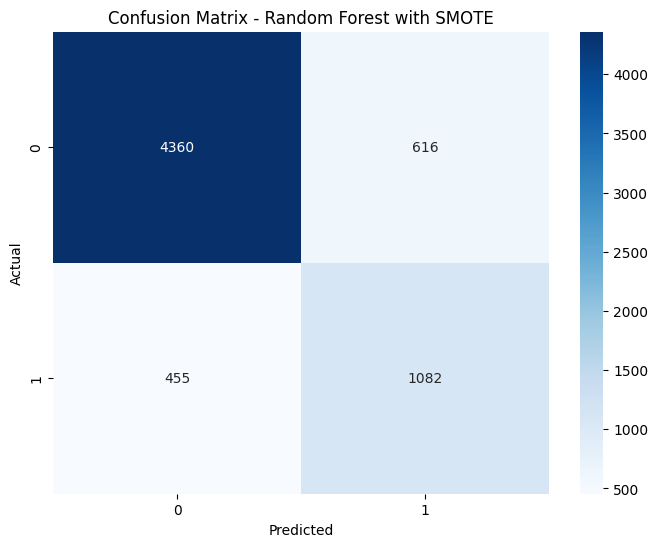

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest with SMOTE')
plt.show()

##Observations

The confusion matrix shows that the model improves detection of the >50K class, increasing true positives while reducing false negatives (455). Although false positives increase (616), recall for the high-income group improves to 70%, indicating the model is more effective at identifying these individuals. This trade-off is acceptable, as the goal is to better capture the minority class, demonstrating the effectiveness of SMOTE in handling class imbalance.

##Feature Importance

In [80]:
import pandas as pd

importances = rf_smote.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances }).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
0,age,0.193430
6,relationship,0.155333
4,marital.status,0.147108
10,hours.per.week,0.094419
8,capital.gain,0.086023
3,education.num,0.085137
5,occupation,0.080255
2,education,0.052314
1,workclass,0.043524
9,capital.loss,0.026806


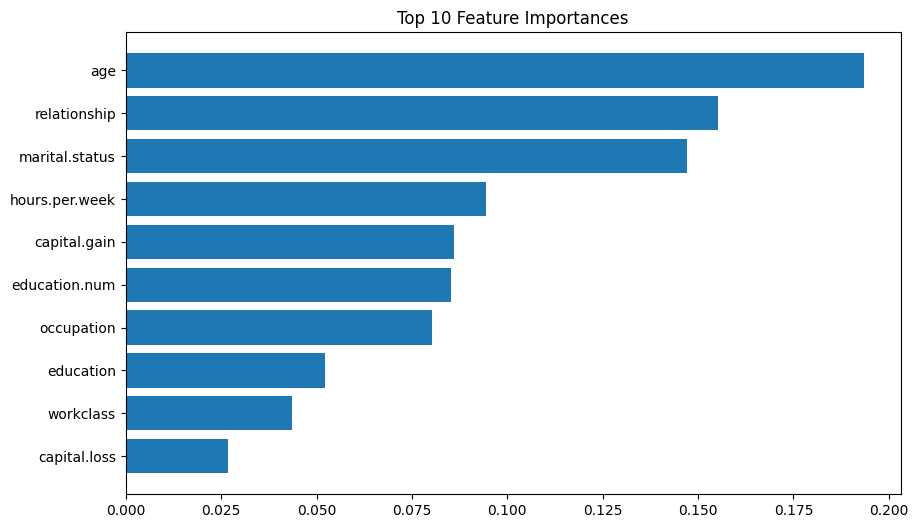

In [81]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.show()

##Observations

The feature importance analysis reveals that age, relationship status, and marital status are the most influential factors in predicting income, surpassing even education-related variables. This suggests that income is strongly influenced by life stage and social structure, in addition to work-related and financial factors such as hours worked and capital gain. The results highlight the importance of relying on data-driven insights rather than assumptions.

##Conclusion

In this project, we performed an end-to-end analysis of income classification using the dataset. The process included data cleaning, exploratory data analysis, feature engineering, and the application of multiple machine learning models to predict whether an individual earns more than 50K per year.

Several models were evaluated, including Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest. While all models showed relatively consistent performance, Random Forest achieved the best overall results, particularly in balancing accuracy and detection of the minority class.

To address class imbalance, SMOTE was applied, resulting in improved recall and F1-score for the >50K category. Although this introduced a slight decrease in precision, the trade-off was acceptable as the model became more effective at identifying high-income individuals.

The confusion matrix further confirmed that the model successfully reduced false negatives and increased true positives for the minority class, demonstrating improved performance in capturing high-income cases.

Feature importance analysis revealed that age, relationship status, marital status, and working hours are the most influential factors in predicting income, highlighting the importance of life stage and socioeconomic context over purely educational variables.

Overall, the final model provides a strong balance between performance and interpretability, and the project demonstrates a complete machine learning workflow from data preprocessing to model evaluation and interpretation.